In [131]:
import numpy as np
import scipy
from os import listdir, makedirs
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [132]:
def custom_dataloader(files):
        """
        # custom_dataloader

        custom_dataloader(config, files)

        Creates a pytorch tensor containing all the batch samples of a specific fold.

        Parameters
        ----------
        - config : dict
                - Dictionary containing the experiment parameters. 
                  See the `autoencoder` class for more details on the config dictionary
        - files : list
                - List of files used in the batch. 
                  All the samples inside the files will be stored as a pytorch tensor.
                  To reduce the memory requirements increase the batch number in the configuration dictionary.

        Returns
        -------
        - samples : torch.tensor
            - Three dimensional tensor containing the batch samples.
              Tensor of shape (N,0,S), where N is the number of sample and S is the size of each sample.    
        """
        folder = f"Datasets/{files}"
        files = listdir(folder)

        TES = np.concatenate([np.fromfile(f"{folder}/{file_name}", dtype=np.float16).reshape((-1,496)) for file_name in files])

        return TES

### Dot-product algorithm

In [138]:
def dot_product_algorithm(dataset, n_average):
    """
    # dot_product_algorithm(dataset, n_average)

    dot_product_algorithm(dataset, n_average)

    Dot-product algorithm for photon detection based on :

    [1] Z. H. Levine et al., ‘Algorithm for finding clusters with a known distribution 
    and its application to photon-number resolution using a superconducting transition-edge sensor’, 
    J. Opt. Soc. Am. B, vol. 29, no. 8, p. 2066, Aug. 2012, doi: 10.1364/JOSAB.29.002066.

    In the source code each equation is referenced using (#) following the equation number used 
    in the paper.
    
    Parameters
    ----------
    - dataset : numpy.ndarray
            - Dataset containing TES traces following the shape (N,S), where N is the number of samples (traces)
              and S is the size of the samples.
    - n_average : float
            - Average number of photon in the dataset.

    Returns
    -------
    - 
    """
    dataset = dataset.astype("float64")
    M = np.shape(dataset)[0]

    # Average all waveforms (2)
    V_mean = np.mean(dataset, axis = 0)

    # dot product of each waveform (3)
    n_eff = n_average * np.sum(V_mean * dataset, axis=1) / np.sum(V_mean * V_mean)

    # Sort waveforms 
    argsort = np.argsort(n_eff)
    sorted_dataset = dataset[argsort]

    def poisson(n, n_average):
       return n_average**n * np.exp(-n_average) / np.math.factorial(n)

    splits = []
    min_ = int(np.min(n_eff))
    max_ = int(np.max(n_eff))
    for n in range(min_ , max_):
      splits.append(np.ceil(M * poisson(n, n_average)))

    return n_eff, sorted_dataset, splits

0 2
0
1


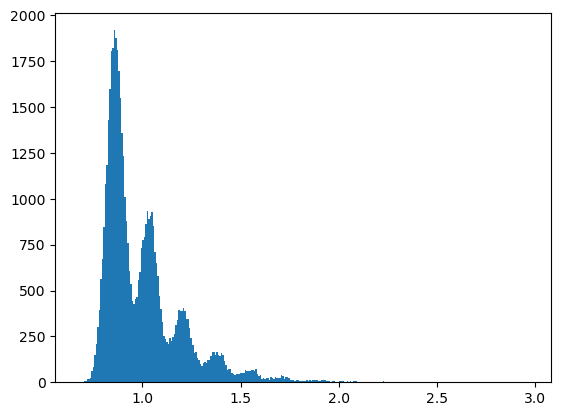

In [139]:
X = custom_dataloader("Oxford")
n_eff, sorted_dataset, splits = dot_product_algorithm(X, n_average = 1)

pl = plt.hist(n_eff,bins=300)

### Poisson-Influenced K-Means Algorithm (PIKA)

In [ ]:
def PIKA(dataset, n_average):
    """
    # PIKA(dataset)

    PIKA(dataset)

    Poisson-Influenced K-Means Algorithm (PIKA) for photon detection based on :

    [1] Z. H. Levine et al., ‘Algorithm for finding clusters with a known distribution 
    and its application to photon-number resolution using a superconducting transition-edge sensor’, 
    J. Opt. Soc. Am. B, vol. 29, no. 8, p. 2066, Aug. 2012, doi: 10.1364/JOSAB.29.002066.

    In the source code each equation is referenced using (#) following the equation number used 
    in the paper.
    
    Parameters
    ----------
    - dataset : numpy.ndarray
            - Dataset containing TES traces following the shape (N,S), where N is the number of samples (traces)
              and S is the size of the samples.

    Returns
    -------
    - 
    """


    